<a href="https://colab.research.google.com/github/GimenesPaula/GimenesPaula/blob/main/Lan%C3%A7amentos_Vendas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bibliotecas Phyton

In [1]:
!pip install requests

In [2]:
!pip install unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 4.3 MB/s eta 0:00:00


In [3]:
!pip install fuzzywuzzy

In [4]:
!pip install dash plotly pandas openpy

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.0/201.0 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 3.6 MB/s eta 0:00:00
  Created wheel for openpy: filename=openpy-0.0.2-py2.py3-none-any.whl size=2783 sha256=4fa9864d077683f6a05174570abe6eb6bd31f6aaa1064c8b69760241a796b8c0
  Stored in directory: /root/.cache/pip/wheels/e5/22/d2/a6092f27b44c5a0f80cec416c15719cbd6a0837912c8187c3f
Successfully built openpy
  Attempting uninstall: wrapt
    Found existing installation: wrapt 2.0.0
    Uninstalling wrapt-2.0.0:
      Successfully uninstalled wrapt-2.0.0
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully 

In [5]:
#Carrega Bibliotecas
import pandas as pd
import numpy as np
import re
from functools import lru_cache
from unidecode import unidecode
import requests
from collections import defaultdict
from fuzzywuzzy import fuzz
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import plotly.express as px
import dash
from dash import dcc, html, Input, Output
from collections import Counter
import ast




/usr/local/lib/python3.12/dist-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


# Fazer Upload planilhas
1.   Lançamentos
2.   Inci
3.   Vendas

In [6]:
#Lançamentos
from google.colab import files
uploaded = files.upload()

Saving Brasil, 30-09-25.xlsx to Brasil, 30-09-25.xlsx


In [7]:
filename = next(iter(uploaded))

In [8]:
# INCI name produtos
from google.colab import files
inci = files.upload()

Saving inci_16_08.xlsx to inci_16_08.xlsx


In [9]:
filename2 = next(iter(inci))

In [10]:
#Vendas Distribuidores
from google.colab import files
dist = files.upload()

Saving sales.xlsx to sales.xlsx


In [11]:
filename4 = next(iter(dist))

# Função

In [12]:


# Função para limpar texto
def limpar(texto):
    if pd.isnull(texto):
        return []
    texto = unidecode(str(texto)).lower()
    texto = re.sub(r'\b\d{2,}\b', '', texto)
    texto = re.sub(r'[.,/\\-]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return [p for p in texto.split(' ') if p]

# Função para extrair chave representativa
def extrair_chave(palavras):
    if not palavras:
        return ''
    relevantes = [p for p in palavras if p not in PALAVRAS_IRRELEVANTES]
    if not relevantes:
        relevantes = palavras
    if len(relevantes) >= 2:
        return f"{relevantes[0]} {relevantes[1]}"
    return relevantes[0]

# Função para gerar chaves para DataFrame com fallback para valor bruto da coluna1
def gerar_chaves(df, coluna1, coluna2=None, coluna3=None):
    palavras1 = df[coluna1].apply(limpar)
    palavras2 = df[coluna2].apply(limpar) if coluna2 else pd.Series([[]] * len(df))
    palavras3 = df[coluna3].apply(limpar) if coluna3 else pd.Series([[]] * len(df))

    def chave_final(idx):
        for lista in [palavras1.iloc[idx], palavras2.iloc[idx], palavras3.iloc[idx]]:
            chave = extrair_chave(lista)
            if chave:
                return chave
        return str(df[coluna1].iloc[idx]).strip().lower()  # fallback para valor bruto da coluna1

    return pd.Series([chave_final(i) for i in range(len(df))], index=df.index)


In [13]:
def formatar_material(coluna):
    def extrair_codigo(texto):
        #Tenta extrair o padrão: 2+ letras + 1+ números
        match = re.search(r'\b([A-Za-z]{2,}\s*\d{1,})\b', texto)
        if match:
            return match.group(1).upper().strip()
    return coluna.apply(extrair_codigo)

In [14]:
#this checks if any combination of INCI as present in Ingredient
def verifica_ingrediente(formula,produto,material):
  quantidade = len(produto.difference(formula))
  if quantidade == 0:
    return material
  return None

In [15]:
#If last code is true, this returns the Descrição name
def procura_produtos(formula, produtos, materiais):
  formula = formula.copy()
  resultados = []
  for prod, mat in zip(produtos, materiais):
    resultado = verifica_ingrediente(formula, prod, mat)
    if resultado is not None:
      formula = formula.difference(prod) ## Para remover os ingredientes já encontrados numa nova busca.
      resultados.append(resultado)
  return resultados

In [16]:
# Função para sinalizar ingredientes do dictOTHERS
def sinaliza_ingredientes(x):
    ingredientes = set().union(*x)  # une todos os sets/listas de ingredientes do grupo
    encontrados = set()
    for ing in ingredientes:
        for palavra in dictOTHERS:
            if palavra.lower() in ing.lower():
                encontrados.add(ing)
    return ', '.join(sorted(encontrados))

In [17]:
#this code transpose data. Used when we bring each category and the number of lauches.
def transpor (df, coluna, linha):
  for cat in df[coluna].unique():
    f = df[coluna] == cat
    df[cat] = df[f][linha]
    f = df[cat].isna()
    df.loc[f, cat] = df.loc[f, cat].apply(lambda x:[])

In [18]:

def to_set(x):
    s = set()
    for item in x:
        if isinstance(item, list):
            s.update(item)
        elif isinstance(item, str):
            s.add(item)
    return list(s)  # Retorna lista para compatibilidade com Excel


In [19]:
def transpor_2 (df, coluna, linha):
  for cat in df[coluna].unique():
    f = df[coluna] == cat
    df[cat] = df[f][linha]
    f = df[cat].isna()
    df.loc[f, cat] = df.loc[f, cat].apply(lambda x:x)

In [20]:
def extrair_estado(texto):
    if pd.isnull(texto):
        return None
    texto = str(texto).strip().lower()
    # Procura por sigla
    for sigla in estados:
        if re.search(r'\b' + re.escape(sigla.lower()) + r'\b', texto):
            return sigla
    # Procura por nome do estado
    for nome, sigla in estados_nome_para_sigla.items():
        if nome in texto:
            return sigla
    return None

In [21]:

# Função para extrair ingredientes exclusivos por subcategoria
def ingredientes_exclusivos_por_categoria(df, categoria, coluna_ingredientes):
    df_cat = df[df['Categoria'].str.contains(categoria, case=False, na=False)]
    subcats = df_cat['Sub-Categoria'].dropna().unique()
    subcat_ingredientes = {}

    for subcat in subcats:
        formulas = df_cat[df_cat['Sub-Categoria'] == subcat][coluna_ingredientes].dropna()
        sets_ingredientes = [set(map(str.strip, ing.split(','))) for ing in formulas]
        comuns = set.intersection(*sets_ingredientes) if sets_ingredientes else set()
        todos = set().union(*sets_ingredientes)
        exclusivos = todos - comuns
        subcat_ingredientes[subcat] = exclusivos

    # Agrupa todos os exclusivos da categoria
    ingredientes_filtrados = set().union(*subcat_ingredientes.values())
    return ingredientes_filtrados

# Função para remover pigmentos (para Maquilagem)
def remover_pigmentos(ingredientes):
    pigmentos = ['mica', 'talc', 'titanium dioxide']
    return [ing for ing in ingredientes if not (
        'ci' in ing.lower() or
        any(pig in ing.lower() for pig in pigmentos)
    )]

# Função para gerar nuvem de palavras
def gerar_nuvem(ingredientes, categoria):
    texto = ', '.join(ingredientes)
    wordcloud = WordCloud(width=1000, height=600, background_color='white').generate(texto)
    plt.figure(figsize=(12, 7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Nuvem de Palavras - Ingredientes INCI exclusivos ({categoria})', fontsize=16)
    plt.savefig(f"nuvem_INCI_exclusivos_{categoria.lower()}.png")
    plt.show()


#Dicionarios

In [22]:
#Dicionários
PALAVRAS_IRRELEVANTES = {
    'industria', 'comercio', 'cosmetico', 'cosmeticos', 'tecnologia', 'ltda', 'me', 'eireli', 'sa', 'cia', 'comercial', 'ind', ' e ',
    'produtos', 'servicos', 'serviço', 'do', 'da', 'de', 'dos', 'das', 'the', 'group', 'grupo',
    'inc', 'corp', 'corporation', 'associados', 'associado', 'associacao', 'associação', 'holding', 'importadora',
    'exportadora', 'importacao', 'importação', 'exportacao', 'exportação', 'distribuidora', 'distribuidor', 'fabricacao',
    'fabricante', 'comerciante', 'comercio', 'comércio', 'comercial', 'empresa', 'sociedade', 'unipessoal',
    'aerosol', 'aerossol',
}


In [23]:
# Dicionário de siglas e nomes de estados
estados = {
    'AC': 'Acre', 'AL': 'Alagoas', 'AP': 'Amapá', 'AM': 'Amazonas', 'BA': 'Bahia', 'CE': 'Ceará',
    'DF': 'Distrito Federal', 'ES': 'Espírito Santo', 'GO': 'Goiás', 'MA': 'Maranhão', 'MT': 'Mato Grosso',
    'MS': 'Mato Grosso do Sul', 'MG': 'Minas Gerais', 'PA': 'Pará', 'PB': 'Paraíba', 'PR': 'Paraná',
    'PE': 'Pernambuco', 'PI': 'Piauí', 'RJ': 'Rio de Janeiro', 'RN': 'Rio Grande do Norte',
    'RS': 'Rio Grande do Sul', 'RO': 'Rondônia', 'RR': 'Roraima', 'SC': 'Santa Catarina',
    'SP': 'São Paulo', 'SE': 'Sergipe', 'TO': 'Tocantins'
}
# Inverte para buscar por nome também
estados_nome_para_sigla = {v.lower(): k for k, v in estados.items()}


In [24]:
#Dicionário Silicones geral
dictOTHERS = {'methicone':'1', 'Dimethicone':'1','methicone Crosspolymer':'1','methiconol':'1',
              'ylsiloxysilicate':'1', 'ylsilsesquioxane':'1', 'Disiloxane':'1', 'Silica':'1','siloxane':'1'}

In [25]:
#Dicionário de palavras a remover da coluna Ingredientes no Mintel
dictIng = {
    r'\s*and/or\s*': ',',
    r',\s*': ',',
    r'\s*,': ',',
    r'\s*\(and\)\s*': ','
}

# Análise Ferramenta de Vendas

In [26]:
data = '/content/'+filename4
df_sale = pd.read_excel(data)
pd.options.display.max_columns=None
df_sale.nunique()

,0
Distributor (subsidiary),4
WACKER Material No.,63
WACKER Material Name,92
Customer Name,649
Region (State/Province) ship-to (of customer),22
Month of Invoice,9
Quantity actual period,148


In [27]:
# Prepara Relatório
# Limpa e padroniza a coluna 'Material'
df_sale['WACKER Material Name'] = formatar_material(df_sale['WACKER Material Name'].astype(str))
df_sale['Distributor (subsidiary)'] = df_sale['Distributor (subsidiary)'].astype(str)

# Padroniza fabricantes e distribuidores
df_sale['KeyManuf'] = gerar_chaves(df_sale, 'Customer Name')

# Preenche Estado com base na coluna de região inicialmente
df_sale['Estado'] = df_sale['Region (State/Province) ship-to (of customer)'].astype(str)

estado_por_keymanuf = (
    df_sale[df_sale['Estado'].notna() & (df_sale['Estado'] != '')]
    .groupby('KeyManuf')['Estado']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
    .to_dict()
)

def preencher_estado(row):
    if pd.isna(row['Estado']) or row['Estado'] == '' or row['Estado'] == 'nan':
        return estado_por_keymanuf.get(row['KeyManuf'], 'XX')
    return row['Estado']

df_sale['Estado'] = df_sale.apply(preencher_estado, axis=1)

df_final = df_sale.groupby(['KeyManuf', 'Estado']).agg(
               Distributor_Set = ('Distributor (subsidiary)', set),
               Sales_Qnty_2025 = ('WACKER Material Name', lambda x: len({str(i).strip() for i in x if pd.notnull(i)})),
               Sales_Kg_2025 = ('Quantity actual period', 'sum'),
               Sales_2025 = ('WACKER Material Name', to_set),
               )
df_final.to_excel('Resumo_vendas.xlsx')
df_final.head()


,,Distributor_Set,Sales_Qnty_2025,Sales_Kg_2025,Sales_2025
KeyManuf,Estado,,,,
&co e,SP,{FOCUS QUIMICA},3,402.0,"[DM 5, EG 6000, TMS 803]"
2k,SC,{EMBACAPS},2,70.0,"[DM 1000, DM 065]"
3fa,GO,{FOCUS QUIMICA},3,376.0,"[EG 5, GB 1020, OW 2100]"
a mais,PE,{MORAIS DE CASTRO},0,38.0,[]
a p,RN,{MORAIS DE CASTRO},1,50.0,[HC 101]


# Análise Relatórios Lançamentos

In [28]:
#Carrega o banco de dados como tabela
data = '/content/'+filename
df_launches = pd.read_excel(data)
pd.options.display.max_columns = None
df_launches.nunique()

,0
Número do Produto,6220
Data de Publicação,430
Produto,3741
Marca,3495
Empresa,908
Categoria,4
Sub-Categoria,39
Descrição do Produto,6219
Preço por 100g/ml,3218
Preço em moeda local,1333


In [29]:
#Edita Coluna Ano
df_launches['Ano'] = pd.to_datetime(df_launches['Data de Publicação']).dt.year

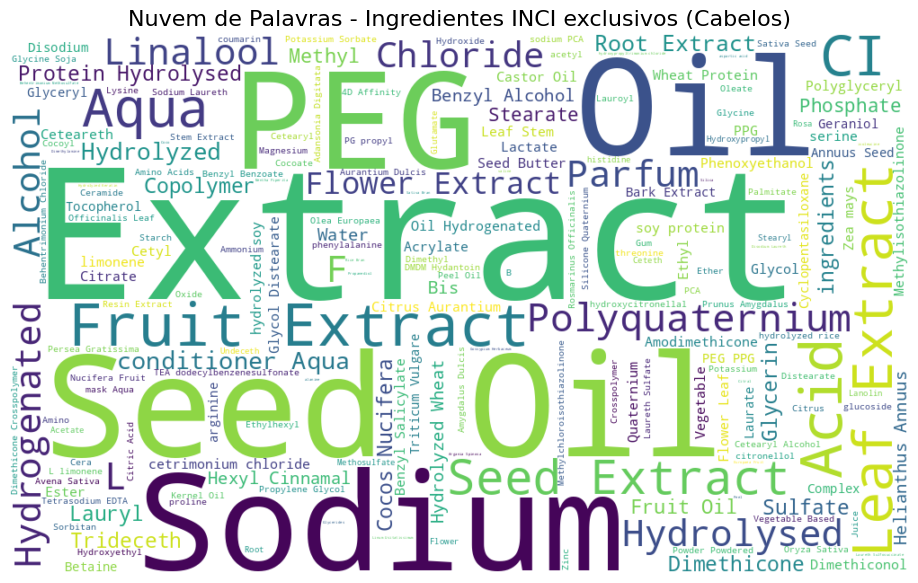

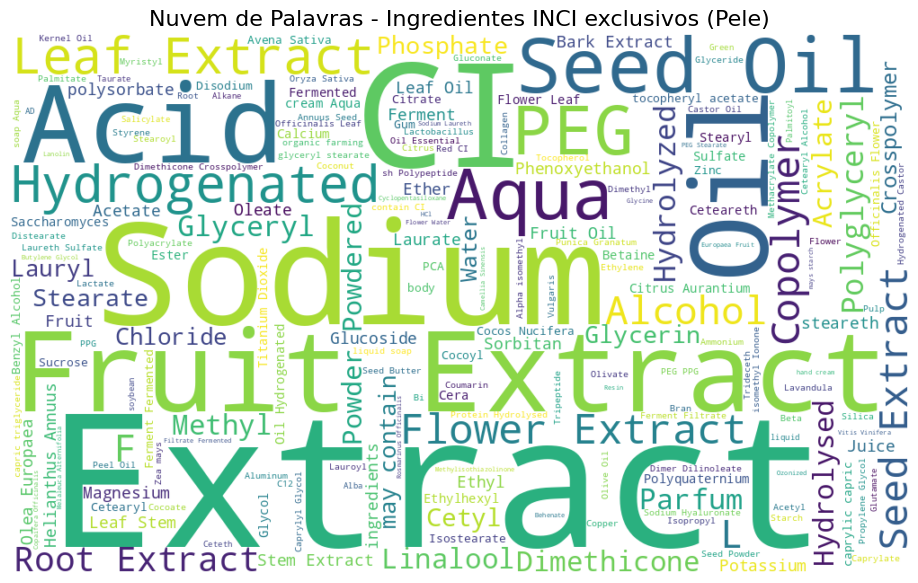

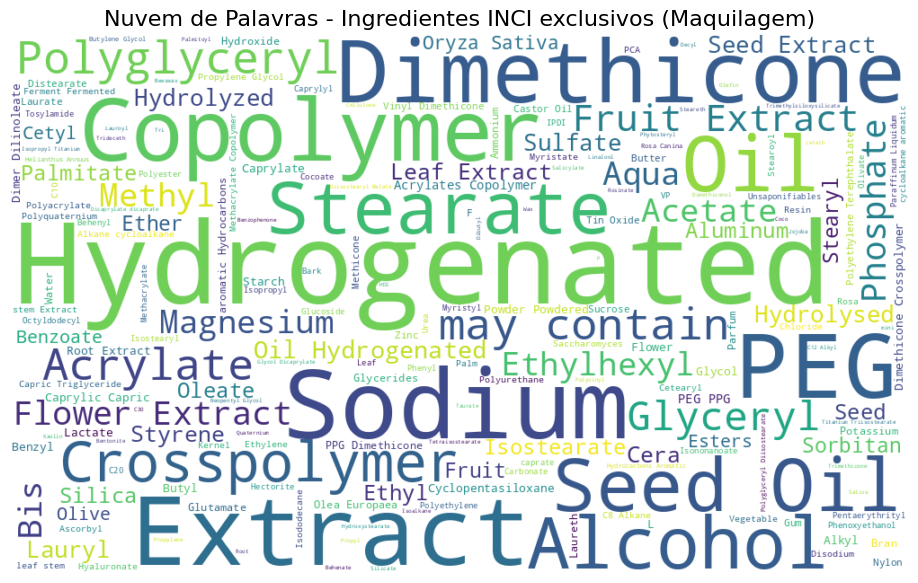

In [30]:
# Gera nuvens para as categorias, apenas para todos os ingrendientes.

# Defina a coluna de referência
coluna_ref = "Ingredients (Standard form)"  # Altere aqui se necessário

# Gera nuvens para as categorias
gerar_nuvem(ingredientes_exclusivos_por_categoria(df_launches, "Cabelos", coluna_ref), "Cabelos")
gerar_nuvem(ingredientes_exclusivos_por_categoria(df_launches, "Pele", coluna_ref), "Pele")
ingredientes_maquiagem = ingredientes_exclusivos_por_categoria(df_launches, "Maquilagem", coluna_ref)
ingredientes_maquiagem_filtrados = remover_pigmentos(ingredientes_maquiagem)
gerar_nuvem(ingredientes_maquiagem_filtrados, "Maquilagem")

##Upload INCI

In [31]:
data = '/content/'+filename2
df_inci = pd.read_excel(data)
pd.options.display.max_columns=None
df_inci.nunique()

,0
Produto,51
Ingrediente,50
Prioridade,3


## Contém Silicone?

In [32]:
df_launches['Silicone'] = df_launches['Ingredients (Standard form)'].str.extract('('+'|'.join(dictOTHERS)+')',expand=False).map(dictOTHERS)


In [33]:
#Edita tabela INCI

df_inci.dropna(inplace=True)
df_inci['Produto'] = formatar_material(df_inci['Produto'])

#Cria uma lista iterável dos ingredientes nos Produtos
df_inci['Ing'] = df_inci['Ingrediente'].str.split(', ').apply(set)
df_inci.sort_values('Prioridade', ascending=True, inplace=True)

In [34]:
# Cria coluna com produtos identificados
df_launches['Ingredients (Standard form)'] = df_launches['Ingredients (Standard form)'].astype(str)
#Cria uma lista iterável das ingredientes cosmeticos
df_launches['Ing'] = (
    df_launches['Ingredients (Standard form)']
    .replace(dictIng, regex=True)
    .str.split(',')
    .apply(set)
)

# Relaciona os ingredientes cosméticos
df_launches['Prod Ident'] = df_launches['Ing'].apply(
    lambda formulacao: procura_produtos(formulacao, df_inci['Ing'], df_inci['Produto'])
)

In [35]:
df_launches['Fabricante']= df_launches['Fabricante'].astype(str)
df_launches['Marca']= df_launches['Marca'].astype(str)
df_launches['Empresa']= df_launches['Empresa'].astype(str)
df_launches['Fabricante'] = df_launches['Fabricante'].fillna(df_launches['Empresa'])
df_launches['KeyManuf'] = gerar_chaves(df_launches, 'Fabricante', 'Empresa', 'Marca')
df_launches['KeyMarca'] = gerar_chaves(df_launches, 'Marca')
df_launches['KeyEmpresa'] = gerar_chaves(df_launches, 'Empresa')

In [36]:
# Exemplo: supondo que sua coluna de empresa é 'Fabricante'
df_launches['Estado'] = df_launches['Manufacturer Company Address'].apply(extrair_estado)

In [37]:
# Preencher os valores ausentes de 'Estado' com base em 'KeyManuf'
missing_estado = df_launches[df_launches['Estado'].isna()]
for index, row in missing_estado.iterrows():
    keymanuf = row['KeyManuf']

    # Buscar registros com o mesmo 'KeyManuf' e 'Estado' não nulo
    estado_valido = df_launches[
        (df_launches['KeyManuf'] == keymanuf) &
        (df_launches['Estado'].notna())
    ]['Estado'].unique()

    # Se houver apenas um valor único de 'Estado', preencher
    if len(estado_valido) == 1:
        df_launches.at[index, 'Estado'] = estado_valido[0]

In [38]:
df_launches['indice']=1
transpor_2(df_launches, 'Categoria', 'indice')

In [39]:
#renomeia coluna categoria
df_launches.rename(columns={'Produtos para Pele':'Pele', 'Produtos para Cabelos':'Cabelos',
                            'Maquilagem': 'Make',
                            'Número do Produto':'Total Lançamentos'},inplace=True)

In [40]:
df_c = df_launches.groupby(['KeyManuf', 'Estado'], dropna=False)[['Pele', 'Cabelos', 'Make']].apply(lambda x:x.count())

In [41]:
#cria tabela que lista o fabricante, o estado e o total de lançamentos, quais tem silicone,
df_b = df_launches.groupby(['KeyManuf', 'Estado'], dropna=False).agg({
    'KeyMarca': to_set,
    'KeyEmpresa': to_set,
    'Total Lançamentos': 'count',
    'Silicone': 'count',
    'Preço por 100g/ml': 'mean',
    'Prod Ident': to_set,
    'Ing': sinaliza_ingredientes
})

In [42]:
#Une tabelas anteriores
df_launches_fab = pd.concat([df_c, df_b], axis=1).reset_index()

In [43]:
df_launches_fab.to_excel('Relatório Lançamentos.xlsx')
df_launches_fab.head()

,KeyManuf,Estado,Pele,Cabelos,Make,KeyMarca,KeyEmpresa,Total Lançamentos,Silicone,Preço por 100g/ml,Prod Ident,Ing
0,&co e,SP,17,0,5,"[pink cheeks, pinkcheeks pro, kind, pinkcheeks...","[ollie, &co e, b o, bscom brasil]",23,17,940.695455,"[GB 150, ES 3007, TMS 803]","C30-45 Alkyl Methicone, Cyclomethicone, Cyclop..."
1,3fa,GO,0,1,0,[weblue],[3fa],1,1,45.000000,[],"Cyclopentasiloxane, Dimethiconol"
2,5 cinco,PR,0,0,1,[5 cinco],[5 cinco],1,1,77.500000,[],"Calcium Aluminum Borosilicate, Silica"
3,5s e,SP,4,0,0,"[fenzza fiore, quintal cultura, fenzza make, f...",[5s e],5,0,NaN,[],
4,a &,MG,1,0,0,[oroskin],[a &],1,1,2.140000,[OW 2100],PEG-12 Dimethicone


In [44]:
def contar_ingredientes_por_categoria(df):
    contagem_por_categoria = {}
    for categoria, grupo in df.groupby('Categoria'):
        contador = Counter()
        for ingredientes in grupo['Ing']:
            contador.update(ingredientes)
        contagem_por_categoria[categoria] = dict(contador)

    # Cria o DataFrame
    df_contagem = pd.DataFrame(contagem_por_categoria).fillna(0).astype(int).sort_index()

    # Adiciona a coluna de soma total por linha
    df_contagem['Total'] = df_contagem.sum(axis=1)

    return df_contagem

# Aplica e salva
tabela_ingredientes = contar_ingredientes_por_categoria(df_launches)
tabela_ingredientes.to_excel("Contagem_Todos_Ingredientes_por_categoria.xlsx")

In [45]:

def contar_ingredientes_por_estado(df):
    contagem_por_estado = {}
    for estado, grupo in df.groupby('Estado'):
        contador = Counter()
        for ingredientes in grupo['Ing']:
            contador.update(ingredientes)
        contagem_por_estado[estado] = dict(contador)
    return pd.DataFrame(contagem_por_estado).fillna(0).astype(int).sort_index()

# Aplica e salva
tabela_ingredientes = contar_ingredientes_por_estado(df_launches)
tabela_ingredientes.to_excel("Contagem_Todos_Ingredientes_por_Estado.xlsx")


## Agrupar relatório Vendas e Projetos

In [46]:
#agrupa lançamentos com vendas e projetos
df_launches_vend_proj = df_launches_fab.merge(df_final, on=['KeyManuf', 'Estado'], how='outer')

In [47]:

def preencher_distributor(row):
    if pd.isna(row['Distributor_Set']) or row['Distributor_Set'] == '':
        if row['Silicone'] != 0 and not pd.isna(row['Silicone']):
            return 'Competitor'
        else:
            return 'No Silicone'
    return row['Distributor_Set']

# Aplicar a função ao DataFrame
df_launches_vend_proj['Distributor_Set'] = df_launches_vend_proj.apply(preencher_distributor, axis=1)


In [48]:
df_launches_vend_proj.head()

,KeyManuf,Estado,Pele,Cabelos,Make,KeyMarca,KeyEmpresa,Total Lançamentos,Silicone,Preço por 100g/ml,Prod Ident,Ing,Distributor_Set,Sales_Qnty_2025,Sales_Kg_2025,Sales_2025
0,&co e,SP,17.0,0.0,5.0,"[pink cheeks, pinkcheeks pro, kind, pinkcheeks...","[ollie, &co e, b o, bscom brasil]",23.0,17.0,940.695455,"[GB 150, ES 3007, TMS 803]","C30-45 Alkyl Methicone, Cyclomethicone, Cyclop...",{FOCUS QUIMICA},3.0,402.0,"[DM 5, EG 6000, TMS 803]"
1,2k,SC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,{EMBACAPS},2.0,70.0,"[DM 1000, DM 065]"
2,3fa,GO,0.0,1.0,0.0,[weblue],[3fa],1.0,1.0,45.000000,[],"Cyclopentasiloxane, Dimethiconol",{FOCUS QUIMICA},3.0,376.0,"[EG 5, GB 1020, OW 2100]"
3,5 cinco,PR,0.0,0.0,1.0,[5 cinco],[5 cinco],1.0,1.0,77.500000,[],"Calcium Aluminum Borosilicate, Silica",Competitor,NaN,NaN,NaN
4,5s e,SP,4.0,0.0,0.0,"[fenzza fiore, quintal cultura, fenzza make, f...",[5s e],5.0,0.0,NaN,[],,No Silicone,NaN,NaN,NaN


# Generate a Report will all information

In [49]:
df_launches_vend_proj.to_excel('Final.xlsx')

In [50]:

# Selecionar as colunas desejadas
colunas = ['KeyManuf', 'Estado', 'Distributor_Set', 'Sales_Kg_2025', 'Sales_2025']

# Criar um novo DataFrame apenas com essas colunas
df_resumo = df_launches_vend_proj[colunas]

# Exibir as primeiras linhas
print(df_resumo.head())

# Se quiser salvar em Excel:
df_resumo.to_excel('resumo_keymanuf.xlsx', index=False)


  KeyManuf Estado  Distributor_Set  Sales_Kg_2025                Sales_2025
0    &co e     SP  {FOCUS QUIMICA}          402.0  [DM 5, EG 6000, TMS 803]
1       2k     SC       {EMBACAPS}           70.0         [DM 1000, DM 065]
2      3fa     GO  {FOCUS QUIMICA}          376.0  [EG 5, GB 1020, OW 2100]
3  5 cinco     PR       Competitor            NaN                       NaN
4     5s e     SP      No Silicone            NaN                       NaN
Arquivo salvo como resumo_keymanuf.xlsx
